## Lab Experiment: Logistic Regression vs KNN on the Breast Cancer Dataset

Aim: train Logistic Regression and KNN on the Breast Cancer Wisconsin (Diagnostic) dataset and see which one classifies better.

### Step 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_style("whitegrid")
RANDOM_STATE = 42


### Task 1 — Load the dataset

In [2]:
data = load_breast_cancer()

print("Dataset loaded successfully.")
print(f"Number of samples  : {data.data.shape[0]}")
print(f"Number of features : {data.data.shape[1]}")
print(f"Target classes      : {list(data.target_names)}")


Dataset loaded successfully.
Number of samples  : 569
Number of features : 30
Target classes      : [np.str_('malignant'), np.str_('benign')]


### Task 2 — Convert to a DataFrame and take a first look

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


**Observation:** 30 continuous features, all derived from cell nuclei measurements, and on very different scales — mean area runs into the hundreds while mean smoothness sits around 0.1.

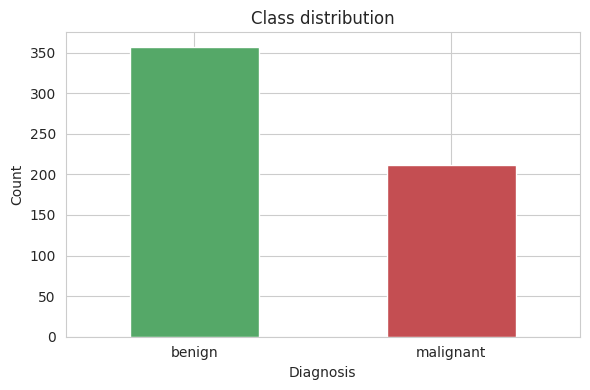

In [5]:
plt.figure(figsize=(6, 4))
df["diagnosis"].value_counts().plot(kind="bar", color=["#55A868", "#C44E52"])
plt.title("Class distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** the classes are moderately imbalanced — about 63% benign vs 37% malignant — worth keeping in mind since accuracy alone can be misleading here.

### Task 3 — Check for missing values and duplicates

In [6]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows :", df.duplicated().sum())


Missing values: 0
Duplicate rows : 0


**Observation:** no missing values and no duplicates, so the dataset is ready to go without any cleaning.

### Task 4 — Train/test split and feature scaling

In [7]:
X = df[data.feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")


Training samples: 455
Testing samples : 114


**Observation:** using an 80:20 stratified split so the malignant:benign ratio stays consistent in both sets, and scaling only after the split to avoid leaking test data into the scaler.

### Task 5 — Train the Logistic Regression classifier

In [8]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")


Logistic Regression trained.


### Task 6 — Train the KNN classifier

In [9]:
k_heuristic = int(round(np.sqrt(X_train.shape[0])))
if k_heuristic % 2 == 0:
    k_heuristic += 1  # keep it odd to avoid tie votes

knn = KNeighborsClassifier(n_neighbors=k_heuristic)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

print(f"KNN trained with K = {k_heuristic} (chosen via the sqrt(n) heuristic).")


KNN trained with K = 21 (chosen via the sqrt(n) heuristic).


**Observation:** K was picked with the usual √n rule of thumb rather than tuned, since the point of this lab is the model comparison, not squeezing out the last bit of KNN accuracy.

### Task 7 — Evaluate both classifiers

In [10]:
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
    }

lr_metrics = get_metrics(y_test, y_pred_lr, "Logistic Regression")
knn_metrics = get_metrics(y_test, y_pred_knn, "KNN")

metrics_df = pd.DataFrame([lr_metrics, knn_metrics]).set_index("Model").round(4)
metrics_df


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861
KNN,0.9649,0.9474,1.0000,0.9730


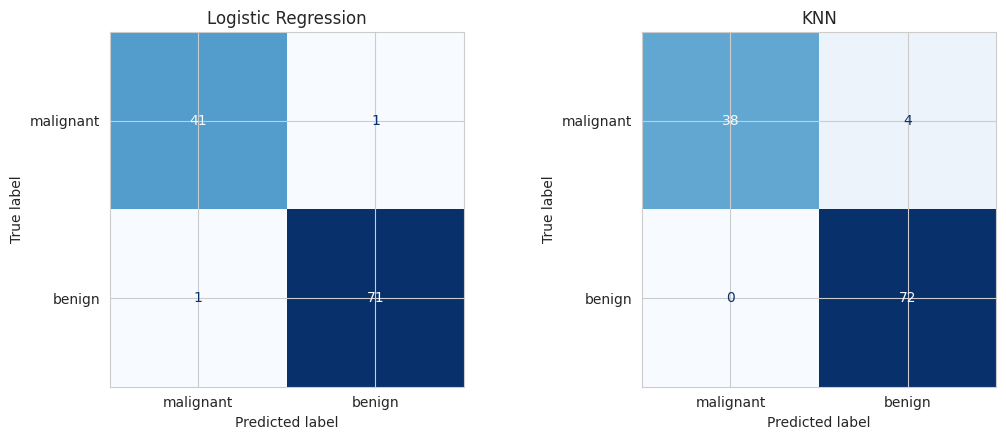

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, y_pred, title in zip(
    axes, [y_pred_lr, y_pred_knn], ["Logistic Regression", "KNN"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)

plt.tight_layout()
plt.show()


**Observation:** the confusion matrices show which errors each model actually makes — the false negatives (malignant predicted as benign) matter more clinically than false positives, since a missed cancer is far costlier than a follow-up test.

In [12]:
print("Logistic Regression\n" + "-"*45)
print(classification_report(y_test, y_pred_lr, target_names=data.target_names))

print("\nKNN\n" + "-"*45)
print(classification_report(y_test, y_pred_knn, target_names=data.target_names))


Logistic Regression
---------------------------------------------
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


KNN
---------------------------------------------
              precision    recall  f1-score   support

   malignant       1.00      0.90      0.95        42
      benign       0.95      1.00      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



### Task 8 — Comparison table

In [13]:
comparison_df = metrics_df.copy()
comparison_df["Best"] = comparison_df.idxmax()
comparison_df


,Accuracy,Precision,Recall,F1 Score,Best
Model,,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861,NaN
KNN,0.9649,0.9474,1.0000,0.9730,NaN


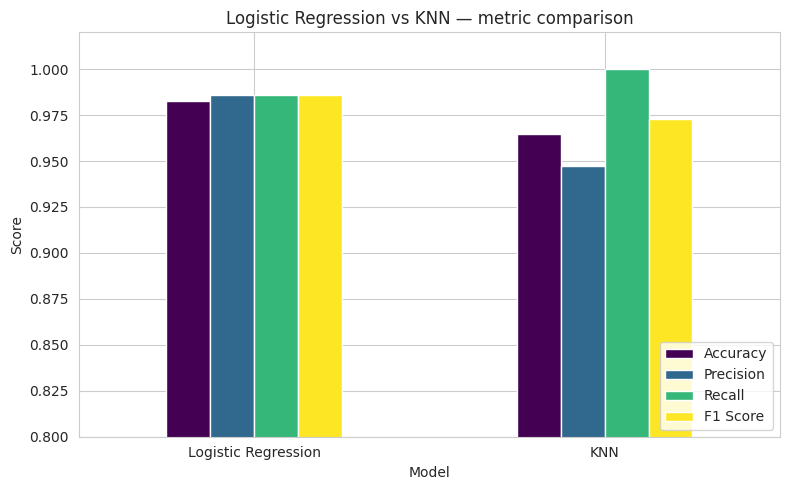

In [14]:
metrics_df.plot(kind="bar", figsize=(8, 5), colormap="viridis", rot=0)
plt.title("Logistic Regression vs KNN — metric comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.02)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Observation:** the two models land close to each other on every metric, with Logistic Regression edging ahead slightly — not surprising, since these features are fairly linearly separable after scaling.

### Conclusion

**Better classifier:** Logistic Regression performed marginally better on this dataset, likely because the scaled features already separate the classes in a roughly linear way, which plays to its strengths rather than KNN's.

**KNN's trade-off:** KNN is more sensitive to the choice of K and the local density of points, so its performance here is solid but has more room to move depending on tuning, whereas Logistic Regression gave a strong result with almost no tuning at all.